In [2]:
import numpy as np
import matplotlib.pyplot as plt
import QST_core_processes as qst #type: ignore

### Generate data of states and associated measurements probabilities

In [3]:
N = 10000  # number of states
SEED = 14
n_qubits = 2

rhos, taus = qst.generate_dataset_of_states_and_probabilities(N, n_qubits, seed=SEED, p_pure=0, eps_pure=1e-5)
data = {'rhos': rhos, 'taus': taus}

### Setting up Projector Matrix and Simulating Shots

In [4]:
P = qst.build_projector_matrix(n_qubits)
P_noisy = qst.simulate_waveplate_misalignment(P, n_qubits)

counts = []
n_shots = 1000
for rho in data['rhos']:
    p = qst.get_measurement_probs_from_P_and_rho(rho, P_noisy, n_qubits)
    p_noisy = qst.simulate_interference_visibility(p)
    counts.append(qst.retrieve_counts_from_n_shots_per_state(p_noisy, n_shots))

data['counts'] = np.stack(counts, axis=0) # easier to work with as a single array
data['P'] = P
data['shots'] = n_shots

In [5]:
qst.add_train_test_split_to_data(data, train_ratio=0.95, seed=SEED)
data_train = qst.get_split(data, "train")
data_test  = qst.get_split(data, "test")

In [18]:
print(data_train.keys())
print(data.keys())

dict_keys(['rhos', 'taus', 'counts', 'shots', 'P'])
dict_keys(['rhos', 'taus', 'counts', 'P', 'shots', 'split'])


This completes the 'setup' portion

For each set of shots data, must then:
- attempt to reconstruct rho using either stokes or Deep Learning
- (ensure consistency in storage)
- compare resulting density matrices with the actual density matrices stored originally

### Implementing Stokes Reconstruction

In [5]:
outputs = {}
outputs['stokes_rhos'] = qst.stokes_reconstruct_dataset(
    P = data['P'],
    counts = data_test['counts'],
    shots = data['shots'],
    n_qubits = n_qubits
)

In [33]:
counts_small = data["counts"][:5]
rhos_true_small = data["rhos"][:5]

mle_rhos = qst.mle_reconstruct_dataset(
    P=data["P"],
    counts=counts_small,
    n_qubits=n_qubits,
    steps=100
)

fids = [qst.fidelity(rhos_true_small[k], mle_rhos[k]) for k in range(len(mle_rhos))]
print("Fidelities:", fids)
print("Mean fidelity:", np.mean(fids))

Fidelities: [0.48291240330258783, 0.17076553277297607, 0.6090922044225985, 0.4637369324450824, 0.4198964063431692]
Mean fidelity: 0.4292806958572828


### Implementing Feed Forward NN

In [8]:
# Naive Neural Network approach
nn_naive = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="mlp",
    loss_type="mse",
    target="rho",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['nn_naive_history'] = nn_naive.fit(data_train)
outputs['nn_naive_rhos'] = nn_naive.predict(data_test)


Epoch 1/100, Loss: 0.5967
Epoch 10/100, Loss: 0.4473
Epoch 20/100, Loss: 0.3864
Epoch 30/100, Loss: 0.3551
Epoch 40/100, Loss: 0.3321
Epoch 50/100, Loss: 0.3161
Epoch 60/100, Loss: 0.3044
Epoch 70/100, Loss: 0.2947
Epoch 80/100, Loss: 0.2892
Epoch 90/100, Loss: 0.2846
Epoch 100/100, Loss: 0.2779


In [6]:
# Physics-informed Neural Network approach
nn_phys = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="mlp",
    loss_type="fidelity",
    target="tau",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    lr=1e-3,
    batch_size=64,
    epochs=100
)
import time
outputs['nn_phys_history'] = nn_phys.fit(data_train)
start = time.time()
outputs['nn_phys_rhos'] = nn_phys.predict(data_test)
end = time.time()
print(f"NN physics prediction time: {end - start:.2f} seconds")

Epoch 1/100, Loss: 39.1165
Epoch 10/100, Loss: 9.2382
Epoch 20/100, Loss: 8.3679
Epoch 30/100, Loss: 7.9446
Epoch 40/100, Loss: 7.7545
Epoch 50/100, Loss: 7.6115
Epoch 60/100, Loss: 7.4652
Epoch 70/100, Loss: 7.2965
Epoch 80/100, Loss: 7.2614
Epoch 90/100, Loss: 7.2133
Epoch 100/100, Loss: 7.1014
NN physics prediction time: 0.00 seconds


### Implementing CNNs

In [9]:
nn_cnn = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="cnn",
    loss_type="fidelity",
    target="tau",
    hidden_sizes=(256 ,256, 256),  
    dropout=0.1,
    cnn_channels=(8, 16),       
    cnn_kernel_size=3,          
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['nn_cnn_history'] = nn_cnn.fit(data_train)
outputs['nn_cnn_rhos'] = nn_cnn.predict(data_test)

Epoch 1/100, Loss: 77.3330
Epoch 10/100, Loss: 21.4143
Epoch 20/100, Loss: 18.2688
Epoch 30/100, Loss: 16.8643
Epoch 40/100, Loss: 15.9476
Epoch 50/100, Loss: 15.2294
Epoch 60/100, Loss: 14.5774
Epoch 70/100, Loss: 14.3288
Epoch 80/100, Loss: 13.8317
Epoch 90/100, Loss: 13.4221
Epoch 100/100, Loss: 12.9556


Naive CNN assumes "close" means close in the projector matrix \
We need to scan between measurements that are "close" in projector geometry

Options:
- Option 1, mix the frequencies before the CNN sees the grid. Take the input and apply a linear transform based on which projector measurements are geometrically similar
- Option 2, treat the 36 measurement settings as nodes in a graph, with adjacency decisions derived from projector similarity (similar to above). Build adjacency matrix and use graph convolution. Gives a more sparse relation between the nodes

For the mixing of the frequencies, there are two options for the kernel change:

Overlap (softer mixing) - mix the 36 frequencies using a kernel derived from projector overlaps, $K_{ab} = Tr(P_aP_b)$. This biases the network to share information between similar measurement settings and then using the CNN

Fidelity (sharper more local mixing) - similar process but uses $|K_{ab} = Tr(P_aP_b)|^2$

**These types of similarity matrix formulation are then used for either options**

In [10]:
nn_cnn_overlap = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="cnn",
    loss_type="fidelity",
    target="tau",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    cnn_channels=(8,16),
    cnn_kernel_size=3,
    cnn_kernel_type="proj_kernel",
    proj_kernel_metric="overlap",
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['cnn_overlap_history'] = nn_cnn_overlap.fit(data_train)
outputs['cnn_overlap_rhos'] = nn_cnn_overlap.predict(data_test)

Epoch 1/100, Loss: 77.4820
Epoch 10/100, Loss: 35.0900
Epoch 20/100, Loss: 33.8785
Epoch 30/100, Loss: 33.1965
Epoch 40/100, Loss: 32.7447
Epoch 50/100, Loss: 32.3304
Epoch 60/100, Loss: 32.0062
Epoch 70/100, Loss: 31.3534
Epoch 80/100, Loss: 30.3347
Epoch 90/100, Loss: 28.4016
Epoch 100/100, Loss: 24.3521


In [11]:
nn_cnn_fidelity = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="cnn",
    loss_type="fidelity",
    target="tau",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    cnn_channels=(8,16),
    cnn_kernel_size=3,
    cnn_kernel_type="proj_kernel",
    proj_kernel_metric="fidelity",
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['cnn_fidelity_history'] = nn_cnn_fidelity.fit(data_train)
outputs['cnn_fidelity_rhos'] = nn_cnn_fidelity.predict(data_test)

Epoch 1/100, Loss: 77.7338
Epoch 10/100, Loss: 34.8431
Epoch 20/100, Loss: 33.3717
Epoch 30/100, Loss: 31.8208
Epoch 40/100, Loss: 21.5910
Epoch 50/100, Loss: 19.4209
Epoch 60/100, Loss: 18.5450
Epoch 70/100, Loss: 17.8352
Epoch 80/100, Loss: 17.2958
Epoch 90/100, Loss: 16.7206
Epoch 100/100, Loss: 16.5037


In [12]:
cnn_graph = qst.NN_Builder(
    n_qubits=n_qubits,
    model_type="cnn",
    loss_type="fidelity",
    target="tau",
    hidden_sizes=(256, 256, 256),
    dropout=0.1,
    cnn_channels=(8,16),
    cnn_kernel_size=3,
    cnn_kernel_type="proj_graph",
    proj_kernel_metric="fidelity",
    proj_graph_top_k = 8,
    lr=1e-3,
    batch_size=64,
    epochs=100
)

outputs['cnn_graph_history'] = cnn_graph.fit(data_train)
outputs['cnn_graph_rhos'] = cnn_graph.predict(data_test)

Epoch 1/100, Loss: 77.7439
Epoch 10/100, Loss: 34.3862
Epoch 20/100, Loss: 28.8757
Epoch 30/100, Loss: 20.0642
Epoch 40/100, Loss: 18.5473
Epoch 50/100, Loss: 17.9075
Epoch 60/100, Loss: 17.1487
Epoch 70/100, Loss: 16.6973
Epoch 80/100, Loss: 16.2929
Epoch 90/100, Loss: 15.9024
Epoch 100/100, Loss: 15.4312


### Analysis

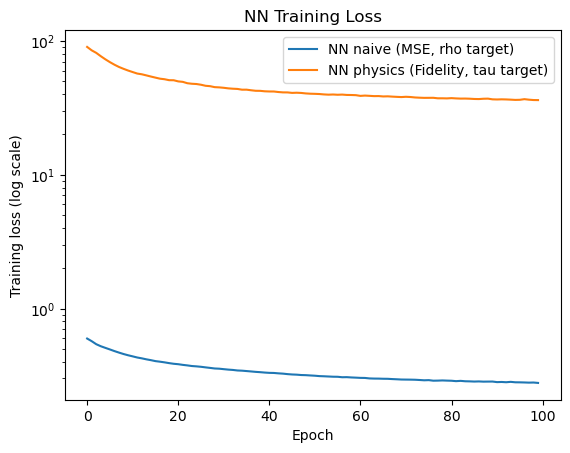

In [10]:
plt.figure()
plt.semilogy(outputs["nn_naive_history"]["loss"], label="NN naive (MSE, rho target)")
plt.semilogy(outputs["nn_phys_history"]["loss"], label="NN physics (Fidelity, tau target)")
# plt.semilogy(outputs["nn_cnn_history"]["loss"], label="NN CNN (MSE, rho target)")
plt.xlabel("Epoch")
plt.ylabel("Training loss (log scale)")
plt.title("NN Training Loss")
plt.legend()
plt.show()

In [7]:
# Compute fidelities

true_rhos = data_test["rhos"]

def fidelities_vs_truth(pred_rhos):
    return np.array([qst.fidelity(true_rhos[k], pred_rhos[k]) for k in range(len(true_rhos))])

F_stokes = fidelities_vs_truth(outputs["stokes_rhos"])
# F_naive  = fidelities_vs_truth(outputs["nn_naive_rhos"])
F_phys   = fidelities_vs_truth(outputs["nn_phys_rhos"])
# F_cnn    = fidelities_vs_truth(outputs["nn_cnn_rhos"])
# F_cnn_overlap = fidelities_vs_truth(outputs["cnn_overlap_rhos"])
# F_cnn_fidelity = fidelities_vs_truth(outputs["cnn_fidelity_rhos"])
# F_cnn_graph = fidelities_vs_truth(outputs["cnn_graph_rhos"])

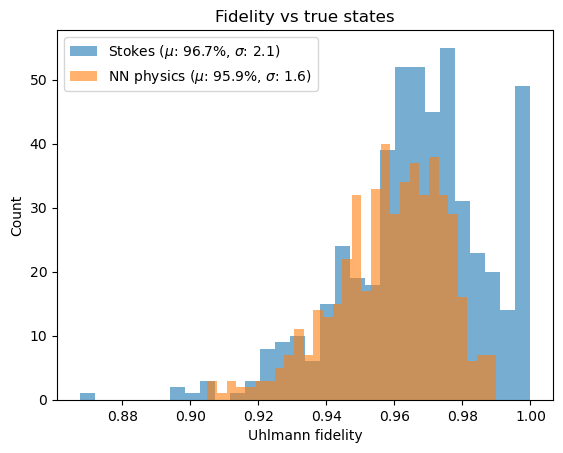

Mean fidelities:
  Stokes: 0.9665529735342068 std: 0.02084531627771916
  Phys  : 0.9586179938609724 std: 0.016155131011508513


In [8]:
plt.figure()
plt.hist(F_stokes, bins=30, alpha=0.6, label=rf"Stokes ($\mu$: {(F_stokes.mean()*100):.1f}%, $\sigma$: {(F_stokes.std()*100):.1f})")
# plt.hist(F_naive,  bins=30, alpha=0.6, label=rf"NN naive ($\mu$: {F_naive.mean()*100:.1f}%, $\sigma$: {(F_naive.std()*100):.1f})")
plt.hist(F_phys,   bins=30, alpha=0.6, label=rf"NN physics ($\mu$: {F_phys.mean()*100:.1f}%, $\sigma$: {(F_phys.std()*100):.1f})")
# plt.hist(F_cnn,    bins=30, alpha=0.6, label=rf"NN CNN ($\mu$: {F_cnn.mean()*100:.1f}%, $\sigma$: {(F_cnn.std()*100):.1f})")
# plt.hist(F_cnn_overlap, bins=30, alpha=0.6, label=rf"NN CNN Overlap Graph ($\mu$: {F_cnn_overlap.mean()*100:.1f}%, $\sigma$: {(F_cnn_overlap.std()*100):.1f})")
# plt.hist(F_cnn_fidelity, bins=30, alpha=0.6, label=rf"NN CNN Fidelity Graph ($\mu$: {F_cnn_fidelity.mean()*100:.1f}%, $\sigma$: {(F_cnn_fidelity.std()*100):.1f})")
# plt.hist(F_cnn_graph, bins=30, alpha=0.6, label=rf"NN CNN Graph ($\mu$: {F_cnn_graph.mean()*100:.1f}%, $\sigma$: {(F_cnn_graph.std()*100):.1f})")


plt.xlabel("Uhlmann fidelity")
plt.ylabel("Count")
plt.title("Fidelity vs true states")
plt.legend(loc='upper left')
plt.show()


print("Mean fidelities:")
print("  Stokes:", F_stokes.mean(), "std:", F_stokes.std())
# print("  Naive :", F_naive.mean(),  "std:", F_naive.std())
print("  Phys  :", F_phys.mean(),   "std:", F_phys.std())
# print("  CNN   :", F_cnn.mean(),    "std:", F_cnn.std())
# print("  CNN Overlap   :", F_cnn_overlap.mean(), "std:", F_cnn_overlap.std())
# print("  CNN Fidelity   :", F_cnn_fidelity.mean(), "std:", F_cnn_fidelity.std())
# print("  CNN Graph   :", F_cnn_graph.mean(), "std:", F_cnn_graph.std())

In [13]:
# Test NN outputs on PSD in states: are they physical

naive_rhos = outputs["nn_naive_rhos"]
phys_rhos = outputs["nn_phys_rhos"]

def is_physical(rho):
    # Check if rho is Hermitian
    if not np.allclose(rho, rho.conj().T):
        return False
    
    # Check if rho is positive semidefinite (PSD)
    eigenvalues = np.linalg.eigvalsh(rho)
    if np.any(eigenvalues < -1e-8):  # Allow for some numerical tolerance
        return False
    
    # Check if trace of rho is 1
    if not np.isclose(np.trace(rho), 1):
        return False
    
    return True

nn_naive_physicality = np.array([is_physical(rho) for rho in naive_rhos])
nn_phys_physicality = np.array([is_physical(rho) for rho in phys_rhos])

print("Naive NN physicality:", nn_naive_physicality.mean())
print("Physics-informed NN physicality:", nn_phys_physicality.mean())
# print("CNN NN physicality:", np.array([is_physical(rho) for rho in outputs["nn_cnn_rhos"]]).mean())

Naive NN physicality: 0.508
Physics-informed NN physicality: 0.998


### CNN Comparison

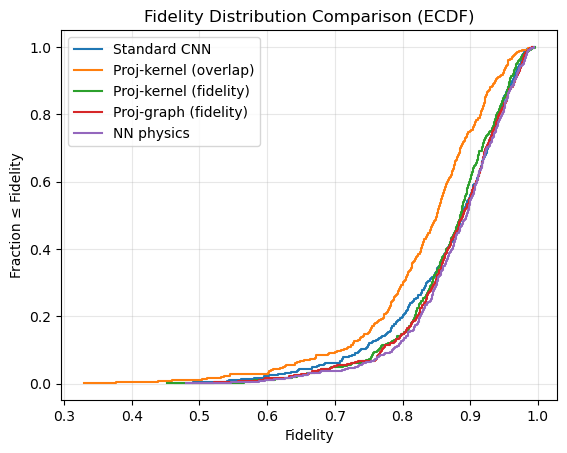

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

plt.figure()

for label, F in [
    ("Standard CNN", F_cnn),
    ("Proj-kernel (overlap)", F_cnn_overlap),
    ("Proj-kernel (fidelity)", F_cnn_fidelity),
    ("Proj-graph (fidelity)", F_cnn_graph),
    ("NN physics", F_phys)
]:
    x, y = ecdf(F)
    plt.step(x, y, where="post", label=label)

plt.xlabel("Fidelity")
plt.ylabel("Fraction ≤ Fidelity")
plt.title("Fidelity Distribution Comparison (ECDF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
def summarize(name, F):
    F = np.asarray(F)
    return {
        "method": name,
        "mean": float(np.mean(F)),
        "std": float(np.std(F, ddof=1)),
        "median": float(np.median(F)),
        "p10": float(np.quantile(F, 0.10)),
        "p90": float(np.quantile(F, 0.90)),
    }

for s in [
    summarize("Standard", F_cnn),
    summarize("Overlap", F_cnn_overlap),
    summarize("Fidelity", F_cnn_fidelity),
]:
    print(s)

{'method': 'Standard', 'mean': 0.8653301910572955, 'std': 0.0938495941980085, 'median': 0.8877553172845647, 'p10': 0.739033778534892, 'p90': 0.9616976007620659}
{'method': 'Overlap', 'mean': 0.8306338959173927, 'std': 0.10134474238160172, 'median': 0.8509930338730578, 'p10': 0.713007908651282, 'p90': 0.9371132279291289}
{'method': 'Fidelity', 'mean': 0.8700207205691619, 'std': 0.0817201341783626, 'median': 0.8856878698042902, 'p10': 0.7654670340663379, 'p90': 0.9582407097672831}


CNNs not performing well could mean a few things:

- Within the 6x6 grid, there are no patterns that are 'translation invariant' ie there's no global filter that discovers a meaningful pattern universally along the grid
- Tomography is inherently global, all measurements contribute to the state, so by searching locally, maybe this information is lost

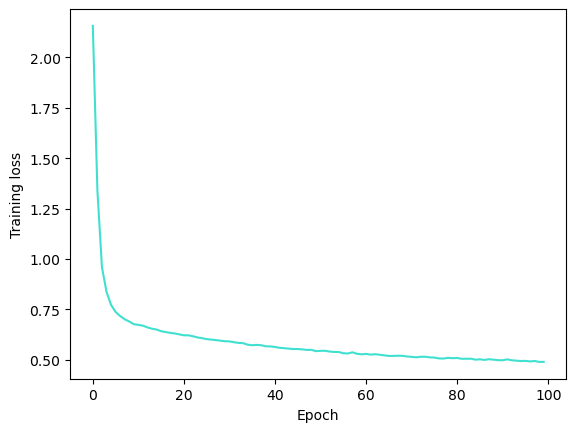

In [95]:
import matplotlib.pyplot as plt
import numpy as np

loss = np.asarray(outputs["nn_naive_history"]["loss"])

plt.figure()
plt.plot(loss, color='turquoise')
plt.xlabel("Epoch")
plt.ylabel("Training loss")
# plt.title("Naïve NN training loss")
# plt.grid(True, alpha=0.3)
plt.show()

In [96]:
import numpy as np
import matplotlib.pyplot as plt

def bar_with_std(methods, Fs, title, width=0.5):
    means = [np.mean(F) for F in Fs]
    stds  = [np.std(F) for F in Fs]

    x = np.arange(len(methods))

    plt.figure(figsize=(8,5))

    bars = plt.bar(
        x, means,
        yerr=stds,
        width=width,
        capsize=6,
        color='turquoise',
        edgecolor='dimgrey',
        ecolor='dimgrey',
        zorder=3
    )

    plt.xticks(x, methods)
    plt.ylabel("Mean fidelity")
    # plt.title(title)

    plt.grid(True, axis="y", linestyle="--", alpha=0.3)
    plt.gca().set_axisbelow(True)

    # ---- Place values just below error bars ----
    for xi, mean, std in zip(x, means, stds):
        plt.text(
            xi,
            mean - std - 0.01,   # slightly below top of error bar
            f"{mean:.3f}",
            ha='center',
            va='top',
            fontsize=10,
            color='black',
            alpha=0.7
        )

    plt.tight_layout()
    plt.show()

    for m, mu, s in zip(methods, means, stds):
        print(f"{m:>12}: mean={mu:.6f}, std={s:.6f}")

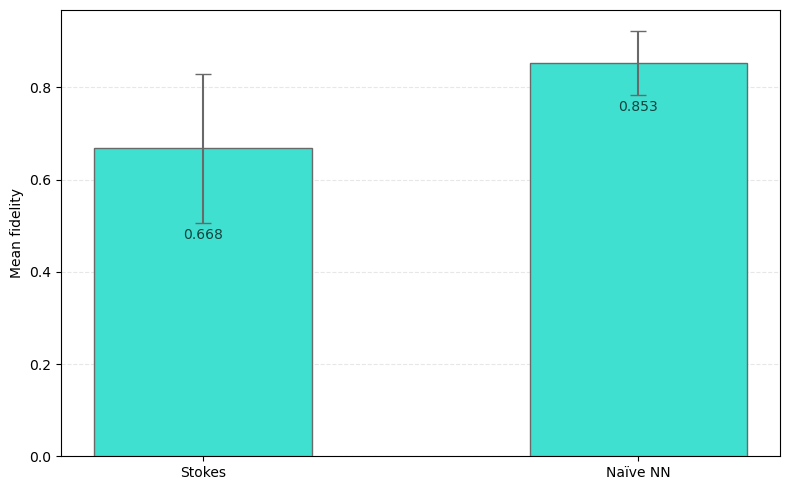

      Stokes: mean=0.667786, std=0.161636
    Naïve NN: mean=0.852655, std=0.069357


In [97]:
bar_with_std(
    methods=["Stokes", "Naïve NN"],
    Fs=[F_stokes, F_naive],
    title="Performance: Classical vs Naïve NN"
)

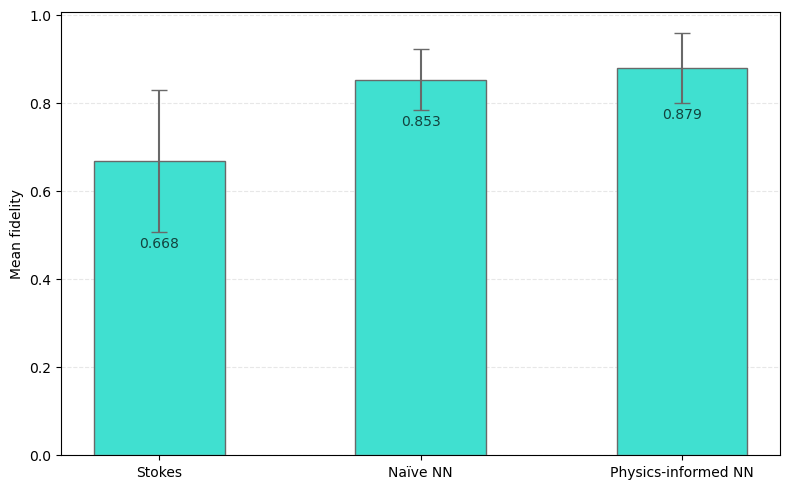

      Stokes: mean=0.667786, std=0.161636
    Naïve NN: mean=0.852655, std=0.069357
Physics-informed NN: mean=0.878736, std=0.079671


In [98]:
bar_with_std(
    methods=["Stokes", "Naïve NN", "Physics-informed NN"],
    Fs=[F_stokes, F_naive, F_phys],
    title="Adding physical constraints improves performance"
)

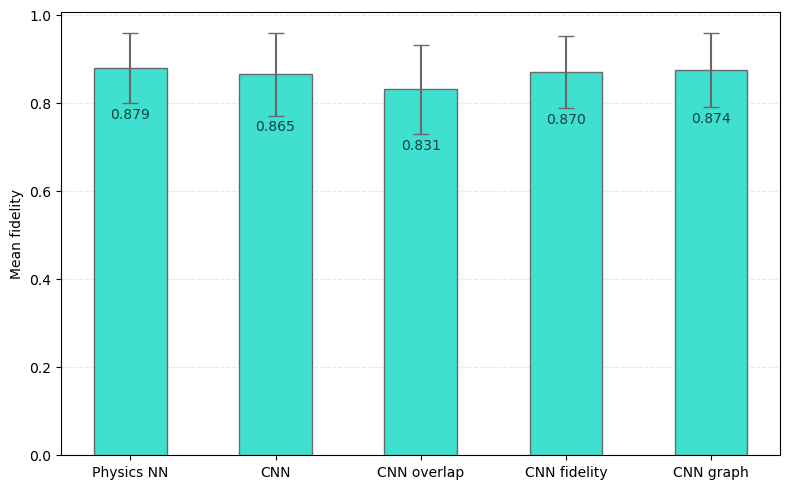

  Physics NN: mean=0.878736, std=0.079671
         CNN: mean=0.865330, std=0.093756
 CNN overlap: mean=0.830634, std=0.101243
CNN fidelity: mean=0.870021, std=0.081638
   CNN graph: mean=0.874050, std=0.083861


In [99]:
bar_with_std(
    methods=[
        "Physics NN",
        "CNN", "CNN overlap", "CNN fidelity", "CNN graph"
    ],
    Fs=[
        F_phys,
        F_cnn, F_cnn_overlap, F_cnn_fidelity, F_cnn_graph
    ],
    title="Architecture variants: marginal gains vs constraint/loss design"
)